<a href="https://colab.research.google.com/github/DD-SQUARED/Scientific-Data-Analysis-Python/blob/main/Instrumental_Magnitude_vs_Airmass_for_All_Filters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

B Filter:
  Extinction Coefficient (a_lambda): 0.4290 ± 0.0186
  Zero Point (ZP): -9.6361
  Correlation coefficient (r): 0.9494 ± 0.0130

V Filter:
  Extinction Coefficient (a_lambda): 0.2560 ± 0.0521
  Zero Point (ZP): -10.0264
  Correlation coefficient (r): 0.5421 ± 0.0927

R Filter:
  Extinction Coefficient (a_lambda): 0.2068 ± 0.0085
  Zero Point (ZP): -10.0698
  Correlation coefficient (r): 0.9539 ± 0.0118

I Filter:
  Extinction Coefficient (a_lambda): 0.1203 ± 0.0119
  Zero Point (ZP): -8.7902
  Correlation coefficient (r): 0.7997 ± 0.0473



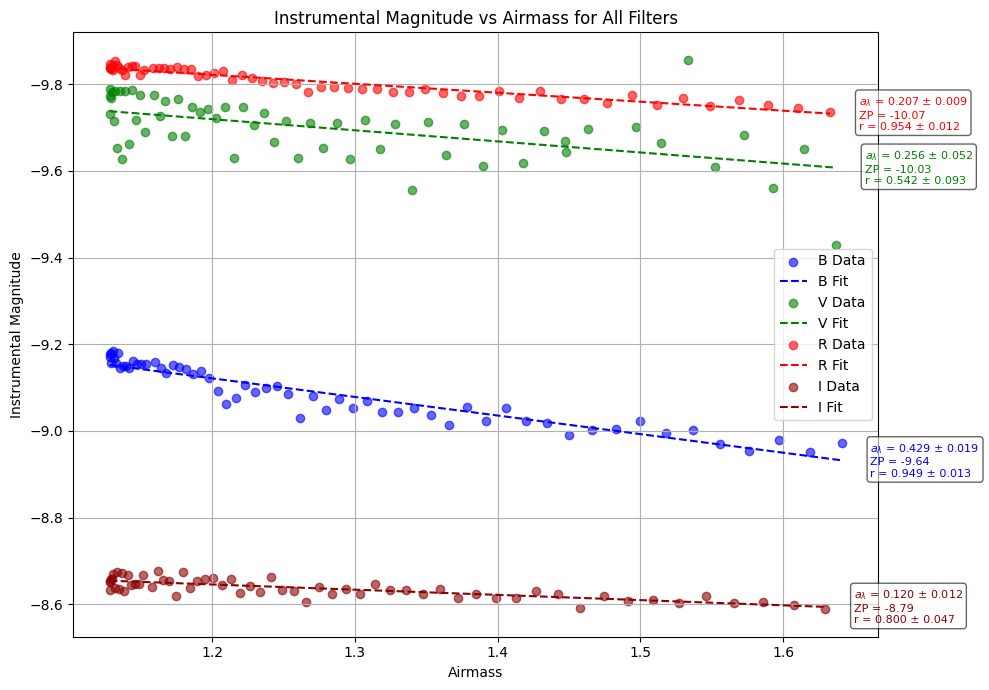

In [ ]:
# Atmospheric Extinction Analysis

## Objective
To analyse the relationship between instrumental magnitude and airmass to determine atmospheric extinction coefficients.

## Key Insights
- Linear relationship between magnitude and airmass observed
- Extinction coefficients vary across different filters (B, V, R, I)
- Results align with expected atmospheric absorption behaviour


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# === Define file names per filter ===
files = {
    "B": "B.csv",
    "V": "V.csv",
    "R": "R.csv",
    "I": "I.csv"
}

# === Color mapping per filter ===
colors = {
    "B": "blue",
    "V": "green",
    "R": "red",
    "I": "darkred"  # You can also use "maroon" or "#8B0000"
}

# === Create a combined figure ===
plt.figure(figsize=(10, 7))

# === Loop through each filter ===
for filt, file in files.items():
    # Read the CSV file
    df = pd.read_csv(file)

    # Check and compute Instrumental Magnitude if necessary
    if "Instrumental_Mag" not in df.columns:
        if "Count_Rate" in df.columns:
            df["Instrumental_Mag"] = -2.5 * np.log10(df["Count_Rate"])
        else:
            print(f"Missing 'Instrumental_Mag' and 'Count_Rate' in {file}")
            continue

    # Drop rows with NaN values in key columns
    df = df.dropna(subset=["Airmass", "Instrumental_Mag"])

    # Number of valid data points
    n = len(df)

    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(df["Airmass"], df["Instrumental_Mag"])
    se_r = (1 - r_value**2) / np.sqrt(n - 2) if n > 2 else np.nan

    # Prepare values for line plot
    x_vals = np.linspace(df["Airmass"].min(), df["Airmass"].max(), 100)
    y_vals = intercept + slope * x_vals

    # Plot data and fit line
    plt.scatter(df["Airmass"], df["Instrumental_Mag"], label=f"{filt} Data", color=colors[filt], alpha=0.6)
    plt.plot(x_vals, y_vals, linestyle='--', color=colors[filt], label=f"{filt} Fit")

    # Annotate the regression results on the plot
    text = (f"$a_λ$ = {slope:.3f} ± {std_err:.3f}\n"
            f"ZP = {intercept:.2f}\n"
            f"r = {r_value:.3f} ± {se_r:.3f}")

    # Place annotation near the end of the fit line
    x_text = x_vals[-1]
    y_text = y_vals[-1]
    plt.text(x_text + 0.02, y_text, text, fontsize=8, color=colors[filt],
             verticalalignment='center',
             bbox=dict(boxstyle="round", facecolor='white', alpha=0.6))

    # Print results to console
    print(f"{filt} Filter:")
    print(f"  Extinction Coefficient (a_lambda): {slope:.4f} ± {std_err:.4f}")
    print(f"  Zero Point (ZP): {intercept:.4f}")
    print(f"  Correlation coefficient (r): {r_value:.4f} ± {se_r:.4f}")
    print()

# === Finalize the plot ===
plt.xlabel("Airmass")
plt.ylabel("Instrumental Magnitude")
plt.title("Instrumental Magnitude vs Airmass for All Filters")
plt.gca().invert_yaxis()
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
